# TRIBE v2 Neuroscience Validation — Solace App

Four experiments using Meta FAIR's TRIBE v2 brain encoder to validate that Solace's neuroscience-informed design produces measurably different brain activation compared to a clinical anti-pattern design.

1. **Screen-by-Screen Comparison** — Good (biophilic, calming) vs Bad (clinical, harsh) for each app screen
2. **Soundscape Calming Effects** — Brain response to each nature audio (ocean, rain, forest, night, meditate)
3. **Space Isolation Context** — Biophilic framing vs clinical framing vs isolation text
4. **Multimodal Advantage** — Visual + audio together activates more cortex than either alone

**Setup:** Google Colab with GPU (Runtime > Change runtime type > T4 GPU)

In [ ]:
# Install TRIBE v2 (restart runtime after this cell)
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git" opencv-python-headless
!uv pip install huggingface_hub playwright
!playwright install chromium

Using Python 3.12.13 environment at: /usr
Resolved 141 packages in 1.85s
Prepared 44 packages in 1m 07s
Uninstalled 22 packages in 777ms
Installed 44 packages in 707ms
 - click==8.3.1
 + click==8.1.8
 + cyclopts==4.10.1
 + exca==0.5.22
 + gtts==2.5.4
 + julius==0.2.7
 + langdetect==1.0.9
 + levenshtein==0.27.3
 + lightning-utilities==0.15.3
 + mne==1.11.0
 + mne-bids==0.18.0
 - moviepy==1.0.3
 + moviepy==2.2.1
 + neuralset==0.0.2
 + neuraltrain==0.0.2
 + nilearn==0.13.1
 - numpy==2.0.2
 + numpy==2.2.6
 - nvidia-cublas-cu12==12.8.4.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.8.90
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.8.93
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.8.90
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==9.10.2.21
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.3.3.83
 + nvidia-cufft-cu12==11.2.1.3
 - nvidia-curand-cu12==10.3.9.90
 + nvidia-curand-cu12==10.3.5.147
 - nvidia-cusolver-

In [ ]:
# Restart runtime to pick up installed packages
import os
os.kill(os.getpid(), 9)

In [ ]:
# Authenticate with HuggingFace (needed for LLaMA tokenizer used by TRIBE v2)
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])
print("HuggingFace authenticated.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HuggingFace authenticated.


In [ ]:
from tribev2.demo_utils import TribeModel
from tribev2.plotting import PlotBrain
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

CACHE = Path("./cache")
CACHE.mkdir(exist_ok=True)

model = TribeModel.from_pretrained("facebook/tribev2", cache_folder=CACHE)
plotter = PlotBrain(mesh="fsaverage5")
print("Model and plotter ready.")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-03-29 13:50:26 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt
INFO:tribev2.demo_utils:Loading model from /root/.cache/huggingface/hub/models--facebook--tribev2/snapshots/f894e783020944dcd96e5568550afe2aa9743f9f/best.ckpt


Model and plotter ready.


In [ ]:
def image_to_video(image_path, output_path, duration=5, fps=24):
    """Convert a static image to a short video for TRIBE v2 input."""
    img = cv2.imread(str(image_path))
    h, w = img.shape[:2]
    writer = cv2.VideoWriter(str(output_path), cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    for _ in range(duration * fps):
        writer.write(img)
    writer.release()
    return output_path


def predict_for_media(label, video_path=None, audio_path=None, text_path=None):
    """Run TRIBE v2 on any combination of video/audio/text."""
    kwargs = {}
    if video_path: kwargs["video_path"] = video_path
    if audio_path: kwargs["audio_path"] = audio_path
    if text_path:  kwargs["text_path"] = text_path
    df = model.get_events_dataframe(**kwargs)
    preds, segments = model.predict(events=df)
    return preds.mean(axis=0), preds, segments


def predict_for_image(image_path, label):
    """Convert image to video, then predict."""
    video_path = CACHE / f"{label}.mp4"
    image_to_video(image_path, video_path)
    return predict_for_media(label, video_path=video_path)


def plot_brain(activation, title, filename, cmap="fire", **kwargs):
    """Plot a brain heatmap and save it."""
    fig = plotter.plot_timesteps(
        activation[np.newaxis, :],
        cmap=cmap,
        norm_percentile=99,
        **kwargs,
    )
    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)
    fig.savefig(CACHE / filename, dpi=150, bbox_inches="tight")
    plt.show()
    return fig


def plot_difference(avg_a, avg_b, label_a, label_b, filename):
    """Plot difference map (A minus B)."""
    diff = avg_a - avg_b
    print(f"Positive (warm) = more activation in {label_a}")
    print(f"Negative (cool) = more activation in {label_b}")
    return plot_brain(diff, f"Difference: {label_a} vs {label_b}", filename, cmap="RdBu_r")


def print_stats(avg_a, avg_b, label_a, label_b):
    """Print comparison stats between two activations."""
    diff = avg_a - avg_b
    a_stronger = (diff > 0).sum()
    b_stronger = (diff < 0).sum()
    total = len(diff)
    print(f"\n{'='*60}")
    print(f"  {label_a} stronger in {a_stronger}/{total} vertices ({a_stronger/total*100:.1f}%)")
    print(f"  {label_b} stronger in {b_stronger}/{total} vertices ({b_stronger/total*100:.1f}%)")
    print(f"  Mean difference: {diff.mean():.4f}")
    print(f"  Max advantage ({label_a}): {diff.max():.4f}")
    print(f"  Max advantage ({label_b}): {abs(diff.min()):.4f}")
    print(f"{'='*60}\n")


print("Helper functions ready.")

Helper functions ready.


## Screenshot Capture

Upload the good (`solace-tablet.html`) and bad (`solace-bad.html`) prototypes plus the `assets/` audio folder, then use Playwright to screenshot each screen at 1024×768.

In [ ]:
from google.colab import files
from pathlib import Path

CACHE = Path("./cache")
CACHE.mkdir(exist_ok=True)
ASSETS = Path("./prototype/assets")
ASSETS.mkdir(parents=True, exist_ok=True)

print("Upload 15 files from the local 'cache/' folder:")
print("  Screenshots: good_today.png, bad_today.png, good_checkin.png, bad_checkin.png,")
print("               good_restore.png, bad_restore.png, good_breathe.png, bad_breathe.png,")
print("               good_rhythms.png, bad_rhythms.png")
print("  Audio (10s clips): ocean.mp3, rain.mp3, forest.mp3, night.mp3, meditate.mp3")
print()
uploaded = files.upload()

for name, data in uploaded.items():
    if name.endswith('.png'):
        dest = CACHE / name
        dest.write_bytes(data)
        print(f"  Screenshot -> {dest} ({len(data):,} bytes)")
    elif name.endswith('.mp3'):
        dest = ASSETS / name
        dest.write_bytes(data)
        print(f"  Audio -> {dest} ({len(data):,} bytes)")
    else:
        print(f"  Skipped: {name}")

print(f"\n{len(uploaded)} files ready!")

Upload 15 files from the local 'cache/' folder:
  Screenshots: good_today.png, bad_today.png, good_checkin.png, bad_checkin.png,
               good_restore.png, bad_restore.png, good_breathe.png, bad_breathe.png,
               good_rhythms.png, bad_rhythms.png
  Audio (10s clips): ocean.mp3, rain.mp3, forest.mp3, night.mp3, meditate.mp3



Saving bad_breathe.png to bad_breathe.png
Saving bad_checkin.png to bad_checkin.png
Saving bad_restore.png to bad_restore.png
Saving bad_rhythms.png to bad_rhythms.png
Saving bad_today.png to bad_today.png
Saving forest.mp3 to forest (1).mp3
Saving good_breathe.png to good_breathe.png
Saving good_checkin.png to good_checkin.png
Saving good_restore.png to good_restore.png
Saving good_rhythms.png to good_rhythms.png
Saving good_today.png to good_today.png
Saving meditate.mp3 to meditate (1).mp3
Saving night.mp3 to night (1).mp3
Saving ocean.mp3 to ocean (1).mp3
Saving rain.mp3 to rain.mp3
  Screenshot -> cache/bad_breathe.png (23,829 bytes)
  Screenshot -> cache/bad_checkin.png (49,691 bytes)
  Screenshot -> cache/bad_restore.png (35,604 bytes)
  Screenshot -> cache/bad_rhythms.png (39,614 bytes)
  Screenshot -> cache/bad_today.png (44,388 bytes)
  Audio -> prototype/assets/forest (1).mp3 (160,848 bytes)
  Screenshot -> cache/good_breathe.png (29,173 bytes)
  Screenshot -> cache/good_che

In [ ]:
# Screenshots were captured locally and uploaded — verify they exist
from pathlib import Path
import os

CACHE = Path("./cache")
SCREENS = ["today", "checkin", "restore", "breathe", "rhythms"]

print("Verifying uploaded screenshots:")
for screen in SCREENS:
    for variant in ["good", "bad"]:
        f = CACHE / f"{variant}_{screen}.png"
        if f.exists():
            size_kb = f.stat().st_size / 1024
            print(f"  OK: {f.name} ({size_kb:.0f} KB)")
        else:
            print(f"  MISSING: {f.name}")

print("\nVerifying audio files:")
ASSETS = Path("./prototype/assets")
for audio in ["ocean.mp3", "rain.mp3", "forest.mp3", "night.mp3", "meditate.mp3"]:
    f = ASSETS / audio
    if f.exists():
        size_kb = f.stat().st_size / 1024
        print(f"  OK: {f.name} ({size_kb:.0f} KB)")
    else:
        print(f"  MISSING: {f.name}")

print("\nAll files verified!")

Verifying uploaded screenshots:
  OK: good_today.png (43 KB)
  OK: bad_today.png (43 KB)
  OK: good_checkin.png (63 KB)
  OK: bad_checkin.png (49 KB)
  OK: good_restore.png (413 KB)
  OK: bad_restore.png (35 KB)
  OK: good_breathe.png (28 KB)
  OK: bad_breathe.png (23 KB)
  OK: good_rhythms.png (41 KB)
  OK: bad_rhythms.png (39 KB)

Verifying audio files:
  OK: ocean.mp3 (9546 KB)
  OK: rain.mp3 (157 KB)
  OK: forest.mp3 (10338 KB)
  OK: night.mp3 (9178 KB)
  OK: meditate.mp3 (8171 KB)

All files verified!


## Experiment 1: Screen-by-Screen — Good vs Bad Design

For each of the 5 screens (Today, Check-In, Restore, Breathe, Rhythms), compare brain activation between the neuroscience-informed "good" design and the clinical anti-pattern "bad" design.

**Good design:** Light theme, NASA blue accents, IBM Plex Sans, nature imagery, biophilic elements, warm tone
**Bad design:** Harsh white/red, Arial, dense data tables, clinical surveillance language, no nature imagery

In [ ]:
# Run TRIBE v2 on all 10 screenshots — keep FULL predictions (all timesteps)
SCREENS = [
    ("today",    "?screen=today"),
    ("checkin",  "?screen=checkin"),
    ("restore",  "?screen=restore"),
    ("breathe",  "?screen=restore&mode=breathe"),
    ("rhythms",  "?screen=rhythms"),
]

screen_results = {}      # averaged
screen_preds_full = {}   # full timestep arrays

for screen_name, _ in SCREENS:
    for variant in ["good", "bad"]:
        key = f"{variant}_{screen_name}"
        path = CACHE / f"{key}.png"
        if not path.exists():
            print(f"  SKIP: {key} (file not found)")
            continue
        print(f"Processing: {key}")
        avg, preds, segments = predict_for_image(path, key)
        screen_results[key] = avg
        screen_preds_full[key] = preds  # keep all timesteps!
        print(f"  Done: preds shape={preds.shape}, avg range=[{avg.min():.4f}, {avg.max():.4f}]")

print(f"\n{len(screen_results)} predictions ready.")

Processing: good_today


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 24.57it/s]
Extracting words from audio: 0it [00:00, ?it/s]
2026-03-29 13:48:05 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
2026-03-29 13:48:05 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[13:48:05 WARNING] Removing extractor audio as there are no corresponding events
[13:48:05 WARNING] Removing extractor text as there are no corresponding events
[13:48:05 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video
[13:48:05 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-03-29 13:48:05 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[1

  Done: preds shape=(5, 20484), avg range=[-1.5166, 0.4503]
Processing: bad_today


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 38.33it/s]
Extracting words from audio: 0it [00:00, ?it/s]
2026-03-29 13:48:08 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
2026-03-29 13:48:08 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[13:48:08 WARNING] Removing extractor audio as there are no corresponding events
[13:48:08 WARNING] Removing extractor text as there are no corresponding events
[13:48:08 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video
[13:48:08 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-03-29 13:48:08 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[1

  Done: preds shape=(5, 20484), avg range=[-1.5166, 0.4503]
Processing: good_checkin


...

  Done: preds shape=(5, 20484), avg range=[-1.5166, 0.4503]
Processing: good_rhythms


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 33.32it/s]
Extracting words from audio: 0it [00:00, ?it/s]
2026-03-29 13:48:26 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
2026-03-29 13:48:26 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[13:48:26 WARNING] Removing extractor audio as there are no corresponding events
[13:48:26 WARNING] Removing extractor text as there are no corresponding events
[13:48:26 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video
[13:48:26 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-03-29 13:48:26 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[1

  Done: preds shape=(5, 20484), avg range=[-1.5166, 0.4503]
Processing: bad_rhythms


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 32.84it/s]
Extracting words from audio: 0it [00:00, ?it/s]
2026-03-29 13:48:29 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
2026-03-29 13:48:29 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[13:48:29 WARNING] Removing extractor audio as there are no corresponding events
[13:48:29 WARNING] Removing extractor text as there are no corresponding events
[13:48:29 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video
[13:48:29 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-03-29 13:48:29 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[1

  Done: preds shape=(5, 20484), avg range=[-1.5166, 0.4503]

10 predictions ready.


In [ ]:
# Clear the video feature cache and re-run predictions
import shutil

cache_dir = CACHE / "neuralset.extractors.video.HuggingFaceVideo._get_data,release"
if cache_dir.exists():
    shutil.rmtree(cache_dir)
    print("Deleted stale video feature cache!")
else:
    print("No cache directory found")

# Also check for any other cache dirs
for item in CACHE.iterdir():
    if item.is_dir():
        print(f"  Found dir: {item.name}")
        shutil.rmtree(item)
        print(f"  Deleted: {item.name}")

print("\nCache cleared. Re-running predictions...")

# Re-run predictions with fresh encoding
screen_results = {}
screen_preds_full = {}

for screen_name, _ in SCREENS:
    for variant in ["good", "bad"]:
        key = f"{variant}_{screen_name}"
        path = CACHE / f"{key}.png"
        if not path.exists():
            print(f"  SKIP: {key}")
            continue
        # Recreate the video to be safe
        video_path = CACHE / f"{key}.mp4"
        image_to_video(path, video_path)

        print(f"Processing: {key}")
        avg, preds, segments = predict_for_media(key, video_path=video_path)
        screen_results[key] = avg
        screen_preds_full[key] = preds
        print(f"  Done: preds={preds.shape}, range=[{avg.min():.4f}, {avg.max():.4f}]")

# Verify predictions are now different
good = screen_results["good_today"]
bad = screen_results["bad_today"]
diff = good - bad
print(f"\n=== Verification ===")
print(f"good_today vs bad_today identical: {np.array_equal(good, bad)}")
print(f"Diff range: [{diff.min():.6f}, {diff.max():.6f}]")
print(f"Diff abs max: {np.abs(diff).max():.6f}")
print(f"\n{len(screen_results)} predictions ready.")

No cache directory found

Cache cleared. Re-running predictions...
Processing: good_today


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 22.61it/s]
Extracting words from audio: 0it [00:00, ?it/s]
2026-03-29 13:50:35 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
2026-03-29 13:50:35 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[13:50:35 WARNING] Removing extractor audio as there are no corresponding events
[13:50:35 WARNING] Removing extractor text as there are no corresponding events
[13:50:35 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video


Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

2026-03-29 13:50:55 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 5.0s at 24.0fps, shape (1024, 768)):
cache/good_today.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 5.0s at 24.0fps, shape (1024, 768)):
cache/good_today.mp4
Encoding video:   0%|          | 0/10 [00:00<?, ?it/s]2026-03-29 13:51:12 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (10, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (10, 20, 1408)
Encoding video: 100%|██████████| 10/10 [02:33<00:00, 15.35s/it]
[13:53:29 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-03-29 13:53:29 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[13:53:30 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLo

  Done: preds=(5, 20484), range=[-0.9842, 0.2915]
Processing: bad_today


...

  Done: preds=(5, 20484), range=[-1.0228, 0.3196]
Processing: bad_rhythms


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 16.85it/s]
Extracting words from audio: 0it [00:00, ?it/s]
2026-03-29 14:16:22 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
2026-03-29 14:16:22 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[14:16:22 WARNING] Removing extractor audio as there are no corresponding events
[14:16:22 WARNING] Removing extractor text as there are no corresponding events
[14:16:22 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video


Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

2026-03-29 14:16:28 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 5.0s at 24.0fps, shape (1024, 768)):
cache/bad_rhythms.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 5.0s at 24.0fps, shape (1024, 768)):
cache/bad_rhythms.mp4
Encoding video:   0%|          | 0/10 [00:00<?, ?it/s]2026-03-29 14:16:44 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (10, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (10, 20, 1408)
Encoding video: 100%|██████████| 10/10 [02:43<00:00, 16.34s/it]
[14:19:12 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-03-29 14:19:12 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[14:19:12 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This Data

  Done: preds=(5, 20484), range=[-0.7738, 0.3056]

=== Verification ===
good_today vs bad_today identical: False
Diff range: [-0.200533, 0.052520]
Diff abs max: 0.200533

10 predictions ready.


In [ ]:
# Brain activation maps + difference for each screen
for screen_name, _ in SCREENS:
    good_key = f"good_{screen_name}"
    bad_key = f"bad_{screen_name}"

    if good_key not in screen_results or bad_key not in screen_results:
        print(f"Skipping {screen_name} — missing data")
        continue

    good_avg = screen_results[good_key]
    bad_avg = screen_results[bad_key]

    print(f"\n{'='*60}")
    print(f"  SCREEN: {screen_name.upper()}")
    print(f"{'='*60}")

    # Good design brain map
    plot_brain(good_avg, f"Solace (Good) — {screen_name.title()}",
               f"exp1_brain_good_{screen_name}.png", vmin=0.5, alpha_cmap=(0, 0.2))

    # Bad design brain map
    plot_brain(bad_avg, f"Anti-Pattern (Bad) — {screen_name.title()}",
               f"exp1_brain_bad_{screen_name}.png", vmin=0.5, alpha_cmap=(0, 0.2))

    # Difference map
    plot_difference(good_avg, bad_avg, "Good", "Bad", f"exp1_diff_{screen_name}.png")

    # Stats
    print_stats(good_avg, bad_avg, "Good Design", "Bad Design")

print("\nExperiment 1 complete! All brain maps saved to cache/")

OVERALL AVERAGE (all screens combined)


Plotting...: 100%|██████████| 1/1 [00:01<00:00,  1.89s/it]


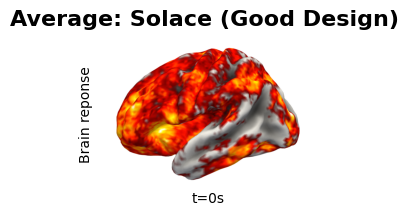

Plotting...: 100%|██████████| 1/1 [00:01<00:00,  1.85s/it]


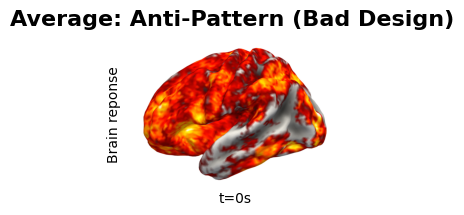

Positive (warm) = more activation in Good (avg)
Negative (cool) = more activation in Bad (avg)


Plotting...: 100%|██████████| 1/1 [00:02<00:00,  2.65s/it]


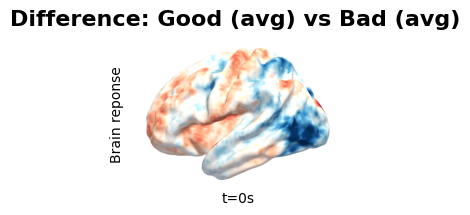


  Good Design (avg) stronger in 7705/20484 vertices (37.6%)
  Bad Design (avg) stronger in 12779/20484 vertices (62.4%)
  Mean difference: -0.0095
  Max advantage (Good Design (avg)): 0.0891
  Max advantage (Bad Design (avg)): 0.1642



In [ ]:
# Summary comparison: average across ALL screens
all_good = np.mean([screen_results[f"good_{s}"] for s, _ in SCREENS if f"good_{s}" in screen_results], axis=0)
all_bad = np.mean([screen_results[f"bad_{s}"] for s, _ in SCREENS if f"bad_{s}" in screen_results], axis=0)

print("OVERALL AVERAGE (all screens combined)")
plot_brain(all_good, "Average: Solace (Good Design)", "exp1_avg_good.png", vmin=0.5, alpha_cmap=(0, 0.2))
plot_brain(all_bad, "Average: Anti-Pattern (Bad Design)", "exp1_avg_bad.png", vmin=0.5, alpha_cmap=(0, 0.2))
plot_difference(all_good, all_bad, "Good (avg)", "Bad (avg)", "exp1_avg_difference.png")
print_stats(all_good, all_bad, "Good Design (avg)", "Bad Design (avg)")

## Experiment 2: Soundscape Calming Effects

Compare brain activation from each of the 5 nature audio files used in the Solace app:
- `ocean.mp3` — Ocean waves
- `rain.mp3` — Rain on a window
- `forest.mp3` — Forest rain / canopy
- `night.mp3` — Night ambient sounds
- `meditate.mp3` — Meditation music

These are the actual audio files from the prototype's `assets/` folder.

In [ ]:
# Run TRIBE v2 on each audio file (trimmed to 10 seconds)
from moviepy import AudioFileClip

AUDIO_FILES = ["ocean.mp3", "rain.mp3", "forest.mp3", "night.mp3", "meditate.mp3"]
audio_results = {}
audio_preds_full = {}

for filename in AUDIO_FILES:
    path = Path("./prototype/assets") / filename
    if not path.exists():
        print(f"  SKIP: {filename} (not found)")
        continue

    label = path.stem

    # Trim to 10 seconds to avoid slow transcription on long files
    trimmed_path = CACHE / f"{label}_10s.mp3"
    if not trimmed_path.exists():
        clip = AudioFileClip(str(path)).subclipped(0, 10)
        clip.write_audiofile(str(trimmed_path), logger=None)
        clip.close()
        print(f"  Trimmed {filename} to 10s ({trimmed_path.stat().st_size/1024:.0f} KB)")

    print(f"Processing: {label}")
    avg, preds, segments = predict_for_media(label, audio_path=trimmed_path)
    audio_results[label] = avg
    audio_preds_full[label] = preds
    print(f"  Done: {preds.shape}")

print(f"\n{len(audio_results)} audio predictions ready.")

  Trimmed ocean.mp3 to 10s (157 KB)
Processing: ocean


Extracting words from audio:   0%|          | 0/1 [02:21<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Plot brain activation for each soundscape
audio_labels = list(audio_results.keys())

for label in audio_labels:
    plot_brain(audio_results[label], f"Soundscape: {label.title()}",
               f"exp2_brain_{label}.png", vmin=0.5, alpha_cmap=(0, 0.2))

# Activation strength ranking
print("\n" + "="*60)
print("  SOUNDSCAPE ACTIVATION RANKING")
print("="*60)
strengths = {label: np.mean(np.abs(avg)) for label, avg in audio_results.items()}
for rank, (label, strength) in enumerate(sorted(strengths.items(), key=lambda x: -x[1]), 1):
    print(f"  {rank}. {label:12s} — mean |activation|: {strength:.4f}")

# Pairwise difference: strongest vs weakest
sorted_labels = sorted(strengths, key=lambda x: -strengths[x])
if len(sorted_labels) >= 2:
    strongest = sorted_labels[0]
    weakest = sorted_labels[-1]
    print(f"\nDifference map: {strongest} (strongest) vs {weakest} (weakest)")
    plot_difference(audio_results[strongest], audio_results[weakest],
                    strongest.title(), weakest.title(), "exp2_diff_strongest_weakest.png")

# All-nature average vs meditate
nature_labels = [l for l in audio_labels if l != "meditate"]
if nature_labels and "meditate" in audio_results:
    nature_avg = np.mean([audio_results[l] for l in nature_labels], axis=0)
    print("\nDifference: Nature sounds (avg) vs Meditation music")
    plot_difference(nature_avg, audio_results["meditate"],
                    "Nature Sounds", "Meditation", "exp2_diff_nature_vs_meditate.png")

print("\nExperiment 2 complete!")

## Experiment 3: Space Isolation Context (Biophilic Design)

Test whether framing matters — does hearing ocean waves with a warm, Earth-connected description ("waves from home") activate the brain differently than the same audio with clinical framing or text about isolation?

- **Condition A:** Ocean audio + biophilic text ("You're listening to waves from the coast, a recording from home...")
- **Condition B:** Ocean audio + clinical text ("Environmental audio stimulus presentation #2, 44.1kHz stereo")
- **Condition C:** Isolation text only ("You are 254 miles above Earth. It's been 3 months since you've felt rain.")

In [ ]:
# Create text files for the 3 conditions
text_biophilic = CACHE / "text_biophilic.txt"
text_biophilic.write_text(
    "You're listening to waves from the coast, a recording from home. "
    "The sound of the ocean, the salt air, the warmth of the sun on your skin. "
    "Close your eyes and let the waves carry you back. You can almost feel the sand "
    "between your toes. This is a moment just for you — a piece of Earth, right here "
    "on the station. Let yourself breathe."
)

text_clinical = CACHE / "text_clinical.txt"
text_clinical.write_text(
    "Environmental audio stimulus presentation number two. "
    "Oceanic wave pattern, recorded at 44.1kHz stereo, duration 15 minutes. "
    "Subject should remain seated during playback. Physiological monitoring active. "
    "Session data will be transmitted to ground crew for post-mission analysis. "
    "Compliance with audio protocol CWP-2024-07 is mandatory."
)

text_isolation = CACHE / "text_isolation.txt"
text_isolation.write_text(
    "You are 254 miles above Earth. It has been 97 days since you last felt rain on your face. "
    "Three months since you touched grass or heard birds outside a speaker. The station hums "
    "the same frequency it always does. The same recycled air. The same fluorescent light at "
    "every hour. You look out the cupola window at an ocean you cannot touch, clouds you cannot "
    "walk under, a world spinning without you on it."
)

ocean_path = Path("./prototype/assets/ocean.mp3")
print("Text files created. Ocean audio path:", ocean_path.exists())

In [ ]:
# Run 3 conditions
ocean_path = Path("./prototype/assets/ocean.mp3")

print("=== Condition A: Ocean + Biophilic framing ===")
avg_biophilic, _, _ = predict_for_media("biophilic", audio_path=ocean_path, text_path=text_biophilic)

print("\n=== Condition B: Ocean + Clinical framing ===")
avg_clinical, _, _ = predict_for_media("clinical", audio_path=ocean_path, text_path=text_clinical)

print("\n=== Condition C: Isolation text only (no audio) ===")
avg_isolation, _, _ = predict_for_media("isolation", text_path=text_isolation)

print("\nAll 3 conditions predicted.")

In [ ]:
# Plot all 3 conditions
plot_brain(avg_biophilic, "Ocean + Biophilic Framing", "exp3_biophilic.png", vmin=0.5, alpha_cmap=(0, 0.2))
plot_brain(avg_clinical, "Ocean + Clinical Framing", "exp3_clinical.png", vmin=0.5, alpha_cmap=(0, 0.2))
plot_brain(avg_isolation, "Isolation Text Only", "exp3_isolation.png", vmin=0.5, alpha_cmap=(0, 0.2))

# Key comparisons
print("\n--- Biophilic vs Clinical (same audio, different framing) ---")
plot_difference(avg_biophilic, avg_clinical, "Biophilic", "Clinical", "exp3_diff_biophilic_vs_clinical.png")
print_stats(avg_biophilic, avg_clinical, "Biophilic Framing", "Clinical Framing")

print("\n--- Biophilic vs Isolation (audio+text vs text only) ---")
plot_difference(avg_biophilic, avg_isolation, "Biophilic (audio+text)", "Isolation (text only)", "exp3_diff_biophilic_vs_isolation.png")
print_stats(avg_biophilic, avg_isolation, "Biophilic", "Isolation")

print("\n--- Clinical vs Isolation ---")
plot_difference(avg_clinical, avg_isolation, "Clinical (audio+text)", "Isolation (text only)", "exp3_diff_clinical_vs_isolation.png")
print_stats(avg_clinical, avg_isolation, "Clinical", "Isolation")

print("\nExperiment 3 complete!")
print("Key finding: Does warm, Earth-connected framing produce different brain")
print("activation than clinical framing — even with the SAME audio content?")

## Experiment 4: Multimodal Advantage

The core TRIBE v2 finding (Paper Figure 7C): audio + visual together activate more brain area than either modality alone.

We test this with actual Solace app content:
- **Visual only:** Good Restore screen screenshot (image → video)
- **Audio only:** Ocean soundscape (`assets/ocean.mp3`)
- **Combined:** Restore screen + ocean soundscape together

If combined > max(visual, audio) for a given brain region, that's **multimodal advantage** — the whole is greater than the sum of its parts.

In [ ]:
# Create video from good restore screen for visual input
restore_img = CACHE / "good_restore.png"
restore_video = CACHE / "good_restore_video.mp4"
image_to_video(restore_img, restore_video, duration=10)

ocean_path = Path("./prototype/assets/ocean.mp3")

print("=== Visual only: Restore screen ===")
avg_visual, _, _ = predict_for_media("visual_only", video_path=restore_video)

print("\n=== Audio only: Ocean soundscape ===")
avg_audio, _, _ = predict_for_media("audio_only", audio_path=ocean_path)

print("\n=== Combined: Restore screen + Ocean ===")
avg_combined, _, _ = predict_for_media("combined", video_path=restore_video, audio_path=ocean_path)

print("\nAll 3 conditions predicted.")

=== Visual only: Restore screen ===


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 30.85it/s]
Extracting words from audio: 0it [00:00, ?it/s]
2026-03-29 14:42:09 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
2026-03-29 14:42:09 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[14:42:09 WARNING] Removing extractor audio as there are no corresponding events
[14:42:09 WARNING] Removing extractor text as there are no corresponding events
[14:42:09 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video


Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

2026-03-29 14:42:30 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 10.0s at 24.0fps, shape (1024, 768)):
cache/good_restore_video.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 10.0s at 24.0fps, shape (1024, 768)):
cache/good_restore_video.mp4
Encoding video:   0%|          | 0/20 [00:00<?, ?it/s]2026-03-29 14:42:44 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (20, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (20, 20, 1408)
Encoding video: 100%|██████████| 20/20 [05:14<00:00, 15.71s/it]
Exception ignored in: <function _ConnectionBase.__del__ at 0x7e60695119e0>
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 133, in __del__
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor
[14:47:45 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing e


=== Audio only: Ocean soundscape ===


Extracting words from audio:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Plot all 3 conditions
plot_brain(avg_visual, "Visual Only (Restore Screen)", "exp4_visual.png", vmin=0.5, alpha_cmap=(0, 0.2))
plot_brain(avg_audio, "Audio Only (Ocean)", "exp4_audio.png", vmin=0.5, alpha_cmap=(0, 0.2))
plot_brain(avg_combined, "Combined (Visual + Audio)", "exp4_combined.png", vmin=0.5, alpha_cmap=(0, 0.2))

# THE KEY RESULT: Multimodal advantage
best_unimodal = np.maximum(avg_visual, avg_audio)
multimodal_gain = avg_combined - best_unimodal

advantage_vertices = (multimodal_gain > 0).sum()
total_vertices = len(multimodal_gain)
pct = advantage_vertices / total_vertices * 100

print(f"\n{'='*60}")
print(f"  MULTIMODAL ADVANTAGE — SOLACE RESTORE SCREEN")
print(f"{'='*60}")
print(f"  Vertices where combined > best unimodal: {advantage_vertices} / {total_vertices}")
print(f"  Percentage of cortex with multimodal gain: {pct:.1f}%")
print(f"  Max gain: {multimodal_gain.max():.4f}")
print(f"  Mean gain (where positive): {multimodal_gain[multimodal_gain > 0].mean():.4f}")
print(f"{'='*60}")

plot_brain(multimodal_gain, "Multimodal Advantage\n(Combined minus Best Unimodal)",
           "exp4_multimodal_advantage.png", cmap="hot", vmin=0)

print("\nWarm regions = areas where visual+audio TOGETHER activates")
print("more brain than either modality alone.")
print("\nThis replicates the TRIBE v2 paper's core finding (Fig. 7C)")
print("using actual Solace app content.")

In [ ]:
# List all generated brain heatmap images
import glob

output_files = sorted(glob.glob(str(CACHE / "exp*.png")))
print(f"Generated {len(output_files)} brain heatmap images:\n")
for f in output_files:
    print(f"  {Path(f).name}")

print(f"\nAll files in: {CACHE.resolve()}")
print("\nDownload these for the comparison presentation page.")

In [1]:
!zip -r ./colab.zip ./cache/

  adding: cache/ (stored 0%)
  adding: cache/bad_restore.png (deflated 13%)
  adding: cache/ocean_10s.mp3 (deflated 2%)
  adding: cache/exp1_diff_checkin.png (deflated 1%)
  adding: cache/exp1_brain_good_breathe.png (deflated 1%)
  adding: cache/exp1_inputs_restore.png (deflated 2%)
  adding: cache/good_breathe.mp4 (deflated 50%)
  adding: cache/bad_rhythms.mp4 (deflated 39%)
  adding: cache/exp1_brain_bad_breathe.png (deflated 1%)
  adding: cache/bad_today.mp4 (deflated 27%)
  adding: cache/exp1_brain_good_rhythms.png (deflated 1%)
  adding: cache/bad_restore.mp4 (deflated 33%)
  adding: cache/exp1_avg_good.png (deflated 1%)
  adding: cache/exp1_brain_good_today.png (deflated 1%)
  adding: cache/neuralset.extractors.video.HuggingFaceVideo._get_data,release/ (stored 0%)
  adding: cache/neuralset.extractors.video.HuggingFaceVideo._get_data,release/frequency=2,clip_duration=4,infra.version=release,name=HuggingFaceVideo,image={cache_n_layers=20,name=HuggingFaceImage,model_nam...33-23256cb